# Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer, PolynomialFeatures
import os
from sklearn.linear_model import LogisticRegression, LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import confusion_matrix, f1_score, roc_curve, auc, accuracy_score
import joblib
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectFromModel
from sklearn.decomposition import PCA


### Base model

F1 score on Training: 0.6397
AUROC for Training: 0.88


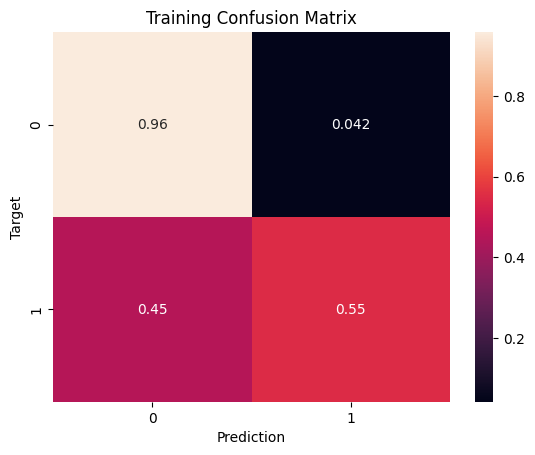

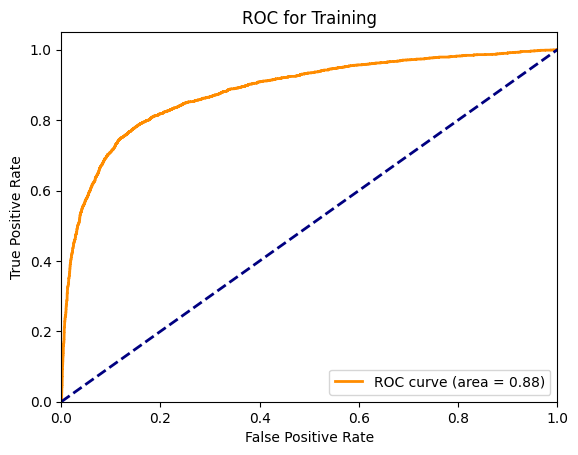

F1 score on Validation: 0.639
AUROC for Validation: 0.88


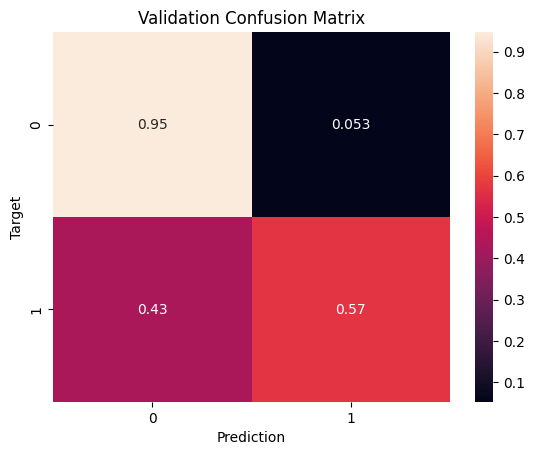

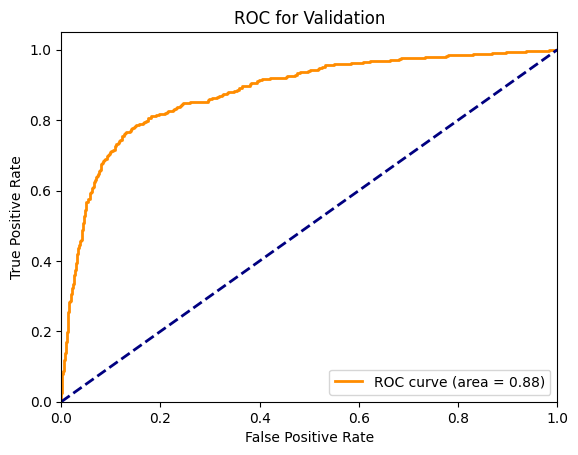

['log_reg_pipeline.joblib']

In [2]:
raw_df = pd.read_csv('train.csv', index_col=0)

target_col = 'Exited'
inputs_cols = ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']

train_df, valid_df = train_test_split(raw_df, test_size=0.2, random_state=42, stratify=raw_df[target_col])

# Створюємо трен. і вал. набори
train_targets = train_df[target_col].copy()
val_targets = valid_df[target_col].copy()

train_inputs = train_df[inputs_cols].copy()
val_inputs = valid_df[inputs_cols].copy()


# Виявляємо числові і категоріальні колонки
numeric_cols = train_inputs.select_dtypes("number").columns
categorical_cols = train_inputs.select_dtypes(exclude="number").columns
map_cols = ['Gender']
encoder_cols = ['Geography']
map_codes = {'Female': 1, 'Male': 0}

def map_columns(df, map_cols, map_codes):

    for col in map_cols:
        df[col] = df[col].map(map_codes)
    
    return df[[col for col in map_cols]]

map_transformer = FunctionTransformer(map_columns, kw_args = {'map_cols': map_cols, 'map_codes': map_codes})

def del_encode_col(df, cols):
    cols_to_drop = []
    for col in cols:
        if (df[col] == 0).all():
            cols_to_drop.append(col)
        else:
            most_frequent = (df[col].value_counts(normalize = True).idxmax())
            cols_to_drop.append(f"{col}_{most_frequent}")
    
    return cols_to_drop

train_cols_to_drop = del_encode_col(train_inputs, encoder_cols)

def drop_encoded_cols(df, cols_to_drop, encoder_cols):
    if not hasattr(df, 'columns'):
        df = pd.DataFrame(df)
    
    df = df.drop(columns = encoder_cols + cols_to_drop, errors='ignore')
    

    return df

dropper = FunctionTransformer(drop_encoded_cols, kw_args = {'cols_to_drop': train_cols_to_drop, 'encoder_cols': encoder_cols})

# Створюємо трансформери для числових і категоріальних колонок
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler()),

])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore')),
])

# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('map', map_transformer, map_cols),
        ('cat', categorical_transformer, encoder_cols)
    ])

# Стоврюємо пайплайн, який спочатку запускає препроцесинг, потім тренуєм модель
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('drop_cols', dropper),
    ('classifier', LogisticRegression(solver='liblinear'))
])

# Тренуємо пайплайн
model_pipeline.fit(train_inputs, train_targets)

# Функція, щоб передбачати і рахувати метрики
def predict_and_plot(targets, inputs, model_pipeline, name = ''):

    pred = model_pipeline.predict(inputs)
    pred_proba = model_pipeline.predict_proba(inputs)[:,1]
    pred_class = (pred_proba >= 0.5).astype(int)


    f1_score_value = f1_score(targets, pred_class, pos_label = True)
    print(f'F1 score on {name}: {round(f1_score_value, 4)}')


    cf = confusion_matrix(targets, pred_class, normalize = 'true')
    plt.figure()
    sns.heatmap(cf, annot = True)
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))


    fpr, tpr, thresholds = roc_curve(targets, pred_proba, pos_label = True)

    roc_auc = auc(fpr, tpr)
    print(f'AUROC for {name}: {round(roc_auc, 2)}')


    plt.figure()
    plt.plot(fpr, tpr, color = 'darkorange', lw =2, label = f'ROC curve (area = {round(roc_auc, 2)})')
    plt.plot([0, 1], [0, 1], color = 'navy', lw = 2, linestyle = '--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC for {name}')
    plt.legend(loc = "lower right")
    plt.show()

    return pred


# Оцінюємо модель на трен і вал даних
train_preds = predict_and_plot(train_targets, train_inputs, model_pipeline, 'Training')
val_preds = predict_and_plot(val_targets, val_inputs, model_pipeline, 'Validation')

# Зберігаємо модель для подальшого використання
joblib.dump(model_pipeline, 'log_reg_pipeline.joblib')


F1 score on Training: 0.7366
AUROC for Training: 0.93


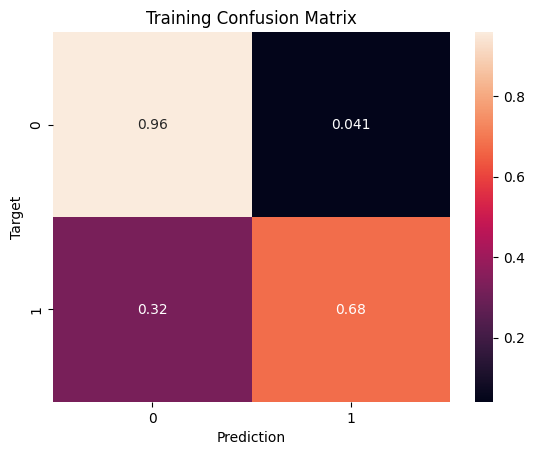

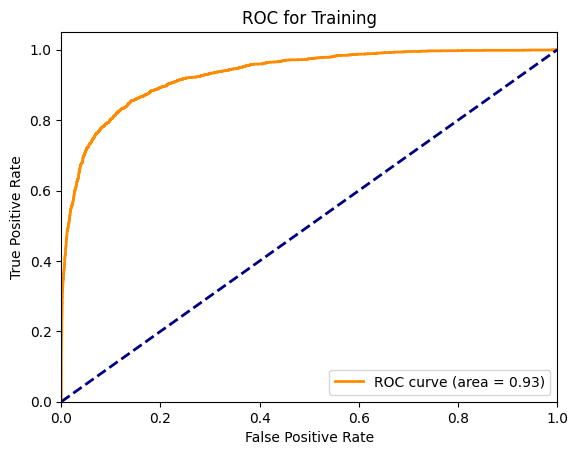

F1 score on Validation: 0.725
AUROC for Validation: 0.93


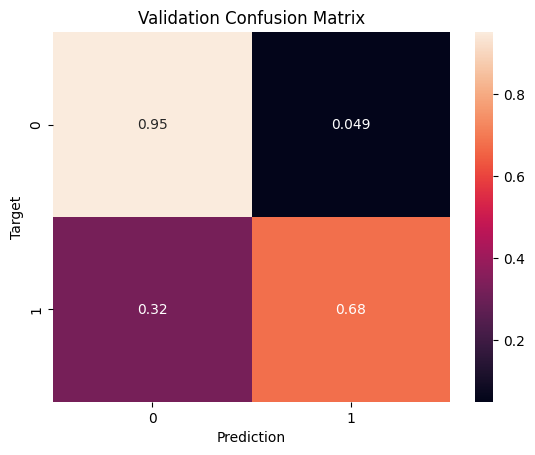

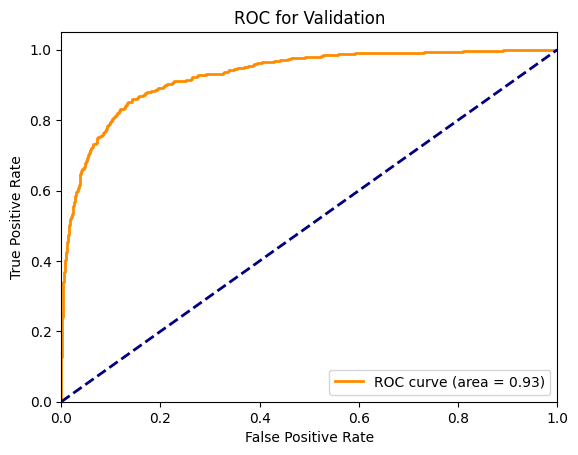

['log_reg_pipeline_poly2.joblib']

In [3]:
raw_df = pd.read_csv('train.csv', index_col=0)

target_col = 'Exited'
inputs_cols = ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']

train_df, valid_df = train_test_split(raw_df, test_size=0.2, random_state=42, stratify=raw_df[target_col])

# Створюємо трен. і вал. набори
train_targets = train_df[target_col].copy()
val_targets = valid_df[target_col].copy()

train_inputs = train_df[inputs_cols].copy()
val_inputs = valid_df[inputs_cols].copy()


# Виявляємо числові і категоріальні колонки
numeric_cols = train_inputs.select_dtypes("number").columns
categorical_cols = train_inputs.select_dtypes(exclude="number").columns
map_cols = ['Gender']
encoder_cols = ['Geography']
map_codes = {'Female': 1, 'Male': 0}
degree = 2

def map_columns(df, map_cols, map_codes):

    for col in map_cols:
        df[col] = df[col].map(map_codes)
    
    return df[[col for col in map_cols]]

map_transformer = FunctionTransformer(map_columns, kw_args = {'map_cols': map_cols, 'map_codes': map_codes})

def del_encode_col(df, cols):
    cols_to_drop = []
    for col in cols:
        if (df[col] == 0).all():
            cols_to_drop.append(col)
        else:
            most_frequent = (df[col].value_counts(normalize = True).idxmax())
            cols_to_drop.append(f"{col}_{most_frequent}")
    
    return cols_to_drop

train_cols_to_drop = del_encode_col(train_inputs, encoder_cols)

def drop_encoded_cols(df, cols_to_drop, encoder_cols):
    if not hasattr(df, 'columns'):
        df = pd.DataFrame(df)
    
    df = df.drop(columns = encoder_cols + cols_to_drop, errors='ignore')
    

    return df

dropper = FunctionTransformer(drop_encoded_cols, kw_args = {'cols_to_drop': train_cols_to_drop, 'encoder_cols': encoder_cols})

# Створюємо трансформери для числових і категоріальних колонок
numeric_transformer_poly2 = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('polinom', PolynomialFeatures(degree = degree))

])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore')),
])

# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor_poly2 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_poly2, numeric_cols),
        ('map', map_transformer, map_cols),
        ('cat', categorical_transformer, encoder_cols)
    ])

# Стоврюємо пайплайн, який спочатку запускає препроцесинг, потім тренуєм модель
model_pipeline_poly2 = Pipeline(steps=[
    ('preprocessor', preprocessor_poly2),
    ('drop_cols', dropper),
    ('classifier', LogisticRegression(solver='liblinear'))
])

# Тренуємо пайплайн
model_pipeline_poly2.fit(train_inputs, train_targets)

# Функція, щоб передбачати і рахувати метрики
def predict_and_plot(targets, inputs, model_pipeline, name = ''):

    pred = model_pipeline.predict(inputs)
    pred_proba = model_pipeline.predict_proba(inputs)[:,1]
    pred_class = (pred_proba >= 0.5).astype(int)


    f1_score_value = f1_score(targets, pred_class, pos_label = True)
    print(f'F1 score on {name}: {round(f1_score_value, 4)}')


    cf = confusion_matrix(targets, pred_class, normalize = 'true')
    plt.figure()
    sns.heatmap(cf, annot = True)
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))


    fpr, tpr, thresholds = roc_curve(targets, pred_proba, pos_label = True)

    roc_auc = auc(fpr, tpr)
    print(f'AUROC for {name}: {round(roc_auc, 2)}')


    plt.figure()
    plt.plot(fpr, tpr, color = 'darkorange', lw =2, label = f'ROC curve (area = {round(roc_auc, 2)})')
    plt.plot([0, 1], [0, 1], color = 'navy', lw = 2, linestyle = '--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC for {name}')
    plt.legend(loc = "lower right")
    plt.show()

    return pred


# Оцінюємо модель на трен і вал даних
train_preds = predict_and_plot(train_targets, train_inputs, model_pipeline_poly2, 'Training')
val_preds = predict_and_plot(val_targets, val_inputs, model_pipeline_poly2, 'Validation')

# Зберігаємо модель для подальшого використання
joblib.dump(model_pipeline_poly2, 'log_reg_pipeline_poly2.joblib')


According to the results, the area under the ROC curve of the model with second-degree polynomials on both the training and validation datasets is the same -- 0.93, which is quite good. As for the F1-score, on the training data the indicator is slightly higher, but within normal limits, which does not indicate the presence of overfitting (and accordingly, underfitting is also absent).

In [4]:
test_raw_df = pd.read_csv('test.csv')
test_raw_df['Exited'] = model_pipeline_poly2.predict_proba(test_raw_df)[:,1]

In [5]:
submission = pd.read_csv('sample_submission.csv')

In [6]:
submission['Exited'] = test_raw_df['Exited']

In [7]:
submission.head()

,id,Exited
0,15000,0.091175
1,15001,0.014792
2,15002,0.072286
3,15003,0.372549
4,15004,0.024421


In [8]:
submission.to_csv('submission_log_reg.csv', index = False)

# Polynomial features

F1 score on Training: 0.7544
AUROC for Training: 0.95


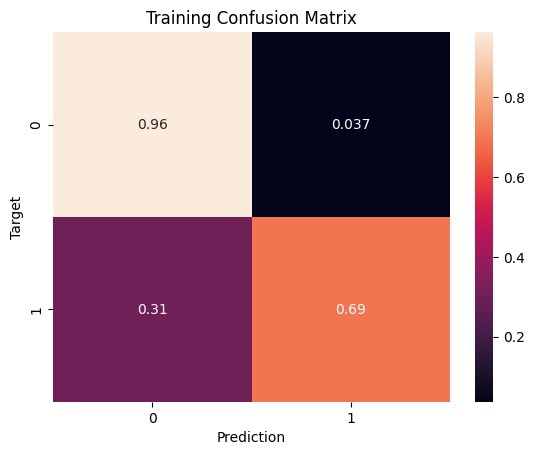

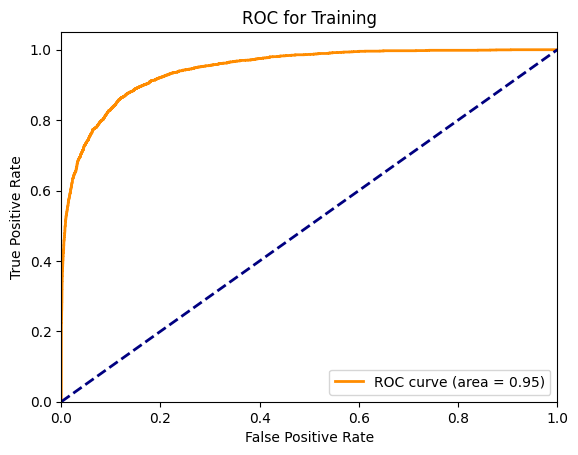

F1 score on Validation: 0.7123
AUROC for Validation: 0.92


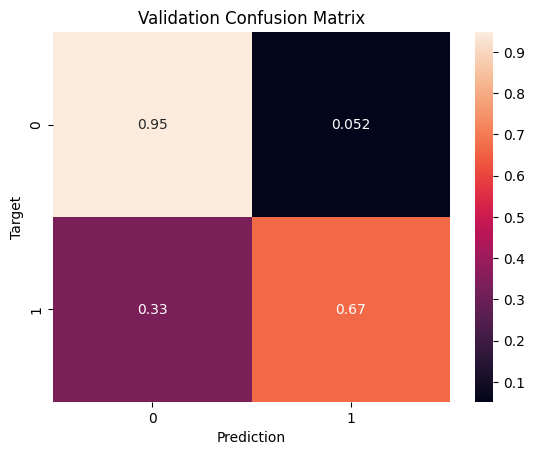

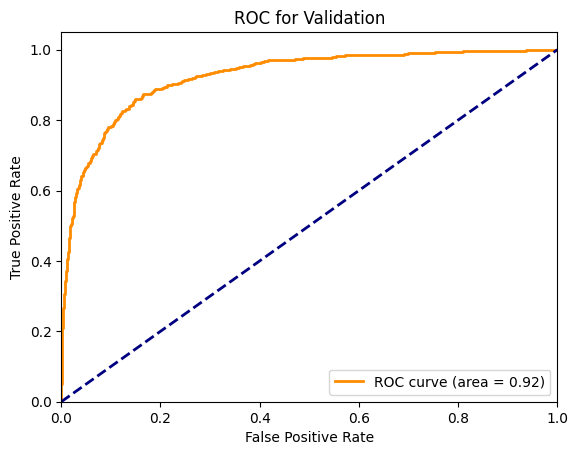

['log_reg_pipeline_poly4.joblib']

In [9]:
raw_df = pd.read_csv('train.csv', index_col=0)

target_col = 'Exited'
inputs_cols = ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']

train_df, valid_df = train_test_split(raw_df, test_size=0.2, random_state=42, stratify=raw_df[target_col])

# Створюємо трен. і вал. набори
train_targets = train_df[target_col].copy()
val_targets = valid_df[target_col].copy()

train_inputs = train_df[inputs_cols].copy()
val_inputs = valid_df[inputs_cols].copy()


# Виявляємо числові і категоріальні колонки
numeric_cols = train_inputs.select_dtypes("number").columns
categorical_cols = train_inputs.select_dtypes(exclude="number").columns
map_cols = ['Gender']
encoder_cols = ['Geography']
map_codes = {'Female': 1, 'Male': 0}
degree = 4

def map_columns(df, map_cols, map_codes):

    for col in map_cols:
        df[col] = df[col].map(map_codes)
    
    return df[[col for col in map_cols]]

map_transformer = FunctionTransformer(map_columns, kw_args = {'map_cols': map_cols, 'map_codes': map_codes})

def del_encode_col(df, cols):
    cols_to_drop = []
    for col in cols:
        if (df[col] == 0).all():
            cols_to_drop.append(col)
        else:
            most_frequent = (df[col].value_counts(normalize = True).idxmax())
            cols_to_drop.append(f"{col}_{most_frequent}")
    
    return cols_to_drop

train_cols_to_drop = del_encode_col(train_inputs, encoder_cols)

def drop_encoded_cols(df, cols_to_drop, encoder_cols):
    if not hasattr(df, 'columns'):
        df = pd.DataFrame(df)
    
    df = df.drop(columns = encoder_cols + cols_to_drop, errors='ignore')
    

    return df

dropper = FunctionTransformer(drop_encoded_cols, kw_args = {'cols_to_drop': train_cols_to_drop, 'encoder_cols': encoder_cols})

# Створюємо трансформери для числових і категоріальних колонок
numeric_transformer_poly4 = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('polinom', PolynomialFeatures(degree = degree))

])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore')),
])

# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor_poly4 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_poly4, numeric_cols),
        ('map', map_transformer, map_cols),
        ('cat', categorical_transformer, encoder_cols)
    ])

# Стоврюємо пайплайн, який спочатку запускає препроцесинг, потім тренуєм модель
model_pipeline_poly4 = Pipeline(steps=[
    ('preprocessor', preprocessor_poly4),
    ('drop_cols', dropper),
    ('classifier', LogisticRegression(solver='liblinear'))
])

# Тренуємо пайплайн
model_pipeline_poly4.fit(train_inputs, train_targets)

# Функція, щоб передбачати і рахувати метрики
def predict_and_plot(targets, inputs, model_pipeline, name = ''):

    pred = model_pipeline.predict(inputs)
    pred_proba = model_pipeline.predict_proba(inputs)[:,1]
    pred_class = (pred_proba >= 0.5).astype(int)


    f1_score_value = f1_score(targets, pred_class, pos_label = True)
    print(f'F1 score on {name}: {round(f1_score_value, 4)}')


    cf = confusion_matrix(targets, pred_class, normalize = 'true')
    plt.figure()
    sns.heatmap(cf, annot = True)
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))


    fpr, tpr, thresholds = roc_curve(targets, pred_proba, pos_label = True)

    roc_auc = auc(fpr, tpr)
    print(f'AUROC for {name}: {round(roc_auc, 2)}')


    plt.figure()
    plt.plot(fpr, tpr, color = 'darkorange', lw =2, label = f'ROC curve (area = {round(roc_auc, 2)})')
    plt.plot([0, 1], [0, 1], color = 'navy', lw = 2, linestyle = '--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC for {name}')
    plt.legend(loc = "lower right")
    plt.show()

    return pred


# Оцінюємо модель на трен і вал даних
train_preds = predict_and_plot(train_targets, train_inputs, model_pipeline_poly4, 'Training')
val_preds = predict_and_plot(val_targets, val_inputs, model_pipeline_poly4, 'Validation')

# Зберігаємо модель для подальшого використання
joblib.dump(model_pipeline_poly4, 'log_reg_pipeline_poly4.joblib')


According to the results, the area under the ROC curve of the model with fourth-degree polynomials on the training and validation datasets showed excellent results -- 0.95 and 0.92, respectively. As for the F1-score, the indicator is also higher on the training data. In this case, we observe the presence of overfitting.

If we compare the two models with polynomials, the model with second-degree polynomials is better and generalizes well, compared to the model with the fourth degree, so for further practical use it is better to use the model with the second-degree polynomial.

# Retraining and regularization

In [10]:
def distribution_plot(df, columns):
    for col in columns:
        
        df_column = df[col]

        fig, axs = plt.subplots(1, 3, figsize = (18, 5))
        fig.suptitle(f'Distribution analysis')

        sns.histplot(df_column, ax = axs[0])
        axs[0].set_title('Histogram')

        stats.probplot(df_column, dist = "norm", plot = axs[1])
        axs[1].set_title('Probability Plot')

        sns.boxplot(x = df_column, ax = axs[2])
        axs[2].set_title('Boxplot')

        plt.tight_layout(rect = [0, 0, 1, 0.95])
        plt.show()

In [11]:
reg_raw_df = pd.read_csv('regression_data.csv')

target_col = 'target'
inputs_cols = reg_raw_df.drop(columns = target_col).columns.tolist()

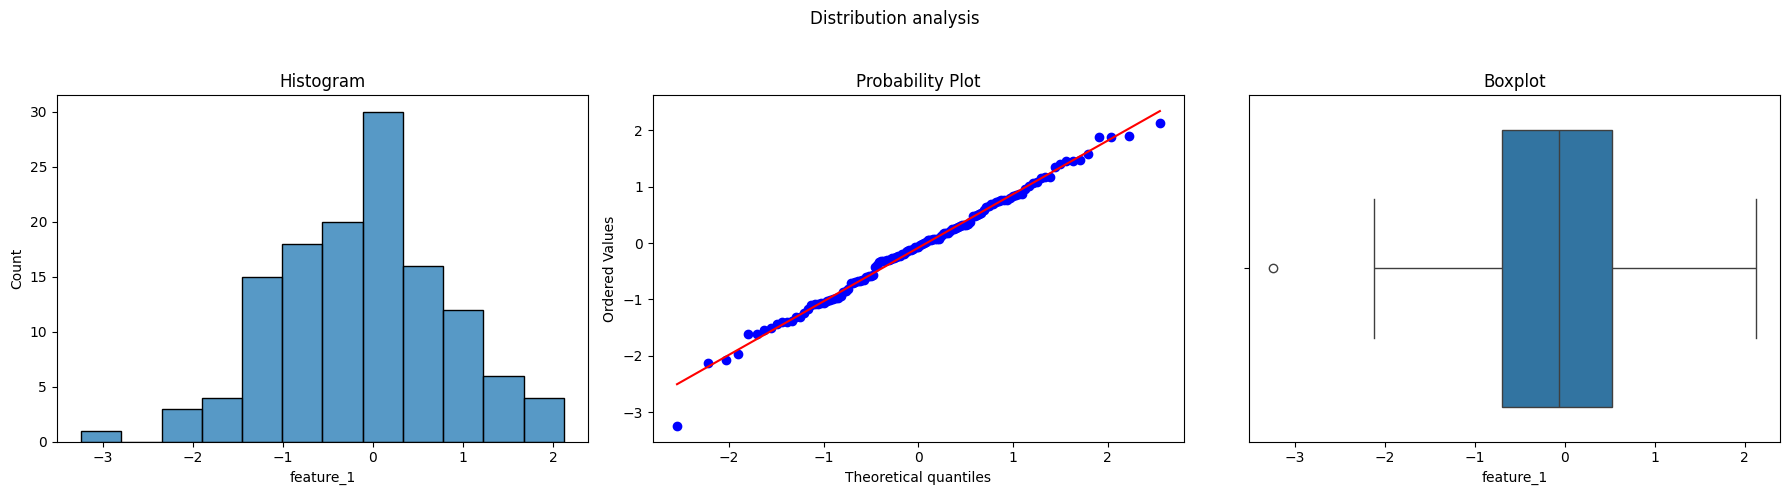

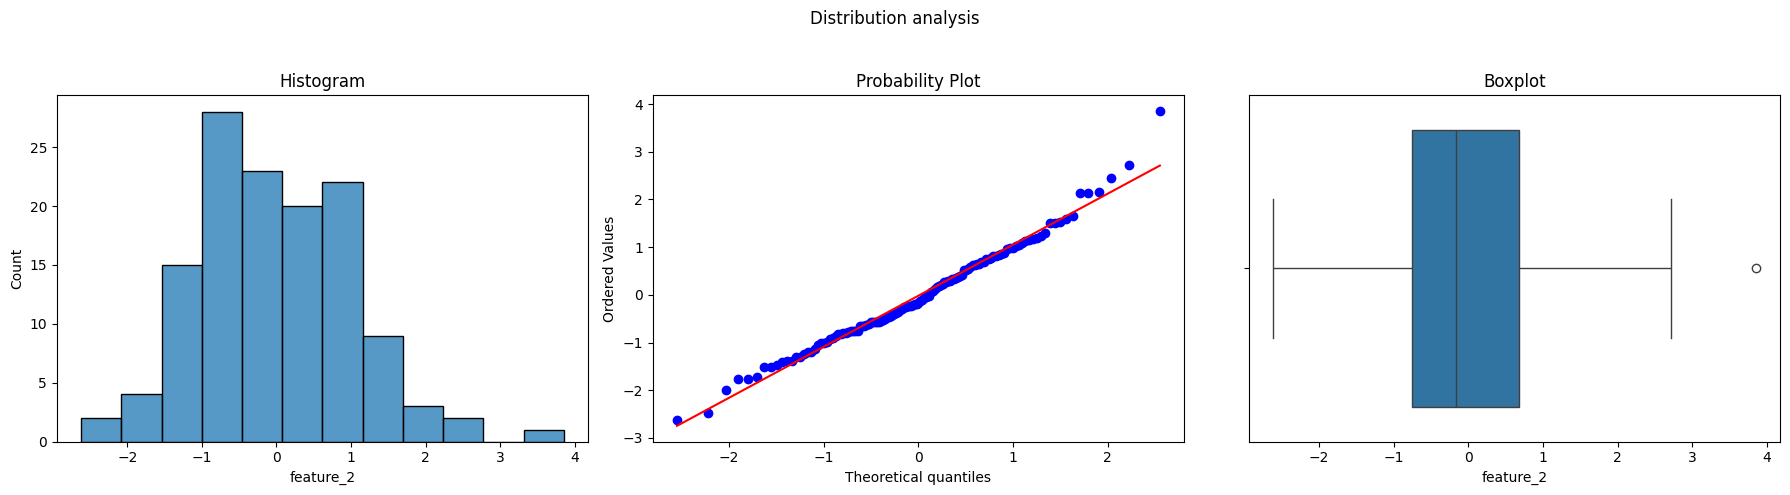

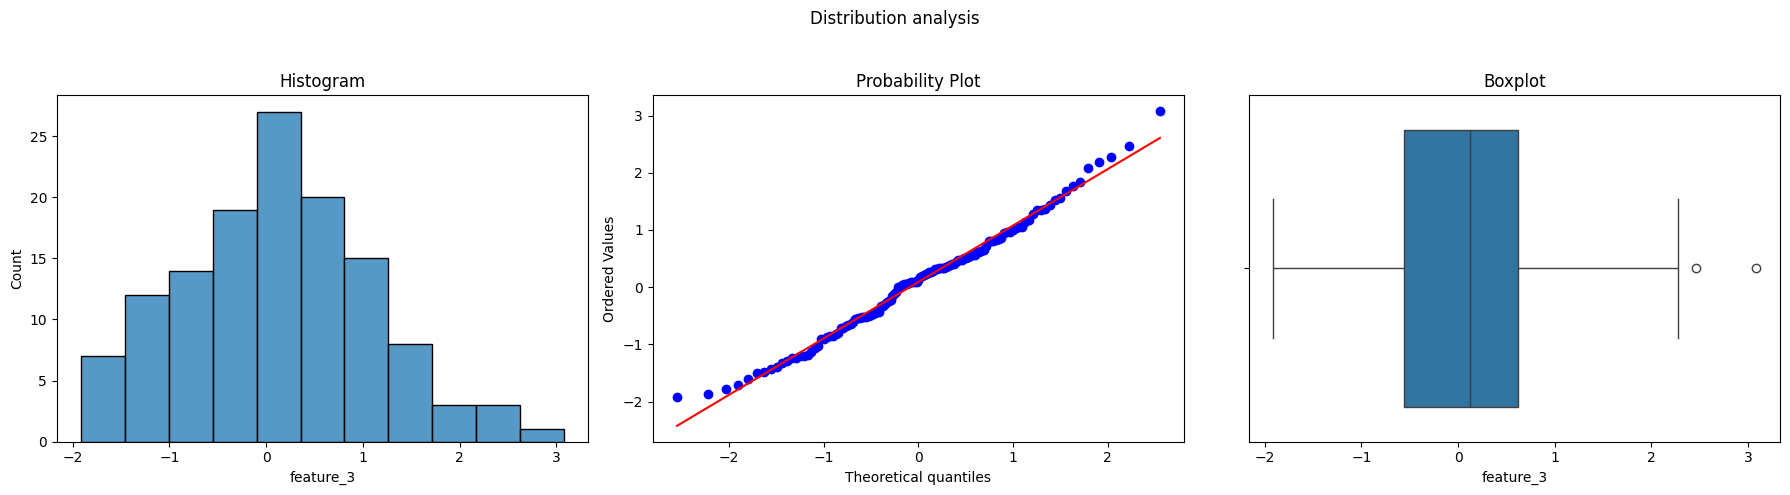

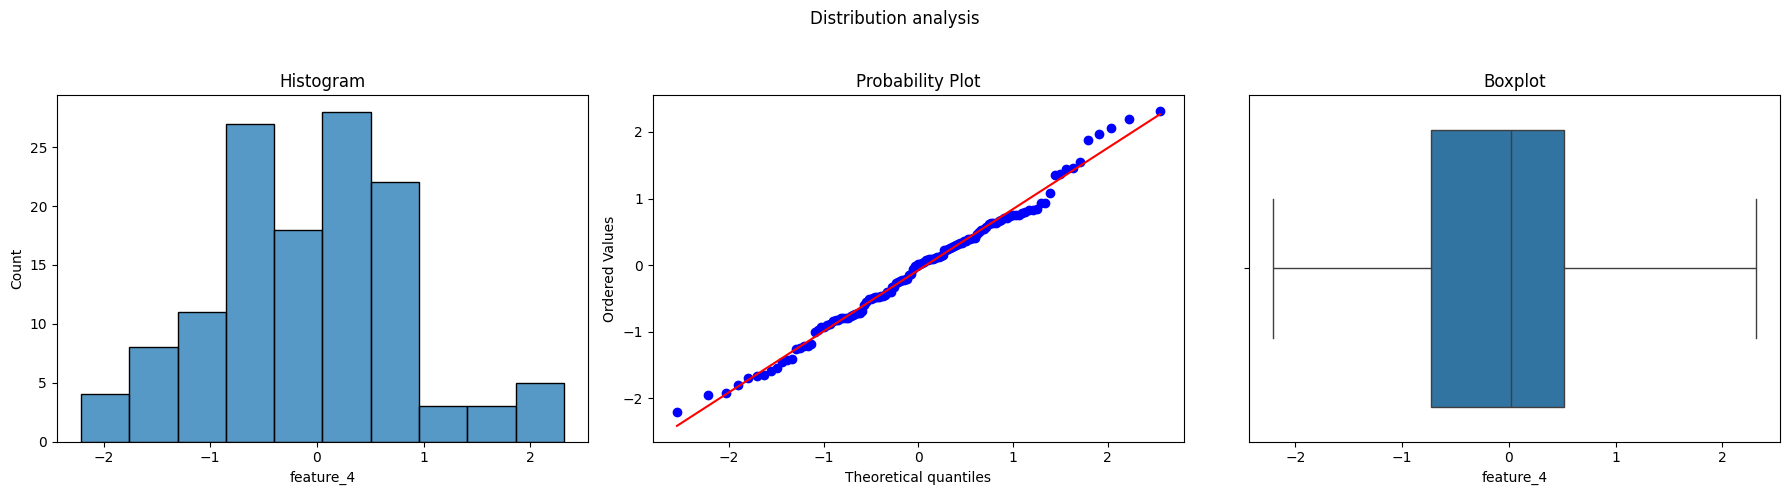

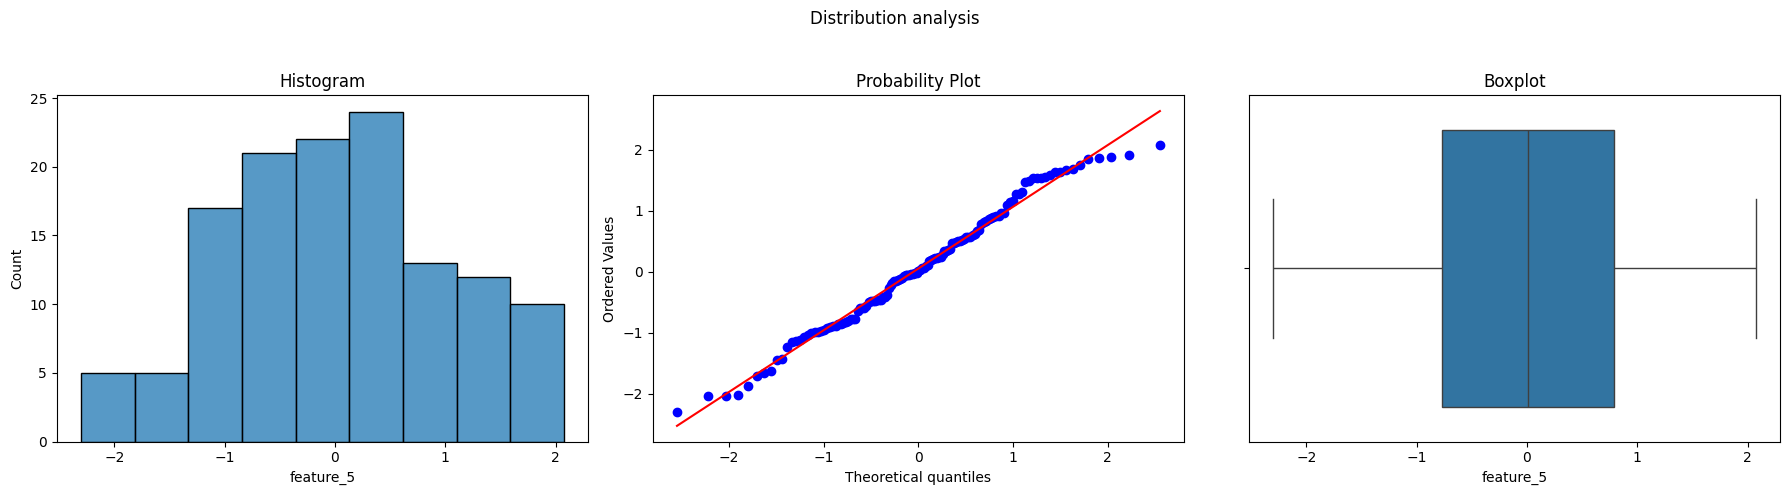

In [12]:
distribution_plot(reg_raw_df, inputs_cols)

RMSE for Training: 0.0
Standard deviation for Training: 44.1342
R^2 for Training: 1.0


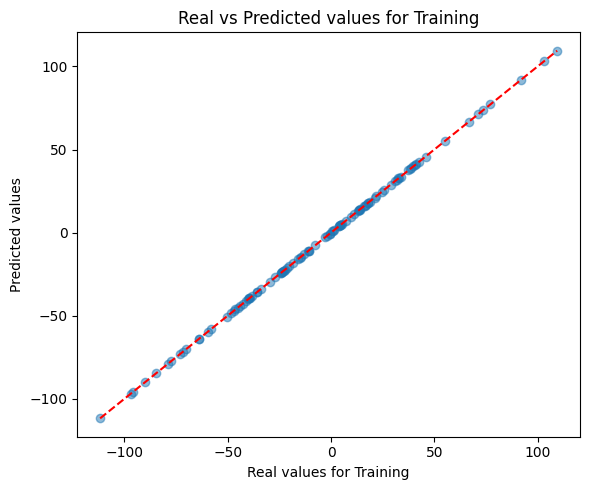

RMSE for Validation: 35.6281
Standard deviation for Validation: 48.3018
R^2 for Validation: 0.4559


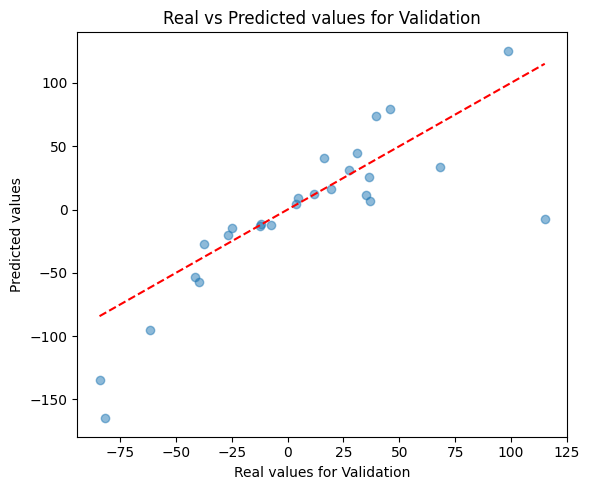

['log_reg_pipeline_poly5.joblib']

In [13]:
train_df, valid_df = train_test_split(reg_raw_df, test_size=0.2, random_state=42)

# Створюємо трен. і вал. набори
train_targets = train_df[target_col].copy()
val_targets = valid_df[target_col].copy()

train_inputs = train_df[inputs_cols].copy()
val_inputs = valid_df[inputs_cols].copy()


# Виявляємо числові і категоріальні колонки
numeric_cols = train_inputs.select_dtypes("number").columns
degree = 5


# Створюємо трансформери для числових і категоріальних колонок
numeric_transformer_poly5 = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('polinom', PolynomialFeatures(degree = degree))

])

# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor_poly5 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_poly5, numeric_cols),
    ])

# Стоврюємо пайплайн, який спочатку запускає препроцесинг, потім тренуєм модель
model_pipeline_poly5 = Pipeline(steps=[
    ('preprocessor', preprocessor_poly5),
    ('regressor', LinearRegression())
])

# Тренуємо пайплайн
model_pipeline_poly5.fit(train_inputs, train_targets)

# Функція, щоб передбачати і рахувати метрики
def predict_and_plot(targets, inputs, model_pipeline, name = ''):

    pred = model_pipeline.predict(inputs)

    rmse_ = np.sqrt(mean_squared_error(targets, pred)).round(4)
    print(f"RMSE for {name}:", rmse_)

    std_ = np.std(targets).round(4)
    print(f"Standard deviation for {name}:", std_)

    r2_ = round(r2_score(targets, pred), 4)

    print(f"R^2 for {name}:", r2_)

    plt.figure(figsize = (6, 5))

    plt.scatter(targets, pred, alpha = 0.5)
    plt.plot([targets.min(), targets.max()],
            [targets.min(), targets.max()],
            'r--')
    plt.xlabel(f"Real values for {name}")
    plt.ylabel("Predicted values")
    plt.title(f"Real vs Predicted values for {name}")
    plt.tight_layout()
    plt.show();

    return pred


# Оцінюємо модель на трен і вал даних
train_preds = predict_and_plot(train_targets, train_inputs, model_pipeline_poly5, 'Training')
val_preds = predict_and_plot(val_targets, val_inputs, model_pipeline_poly5, 'Validation')

# Зберігаємо модель для подальшого використання
joblib.dump(model_pipeline_poly5, 'log_reg_pipeline_poly5.joblib')


The simulation results indicate that the model using the fifth degree polynomial learned the training data, resulting in 100% accuracy. However, we observe overfitting on the test data, since certain points are completely new to the model, and due to the fact that it generalizes poorly, the obtained quality metrics are poor.

# Lasso, Ridge, ElasticNet models

c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.430e+04, tolerance: 2.006e+01
  model = cd_fast.enet_coordinate_descent(
c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_ridge.py:267: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.507e+04, tolerance: 2.006e+01
  model = cd_fast.enet_coordinate_descent(


Результати моделювання з використанням Lasso
RMSE for Training: 8.6167
Standard deviation for Training: 44.1342
R^2 for Training: 0.9619


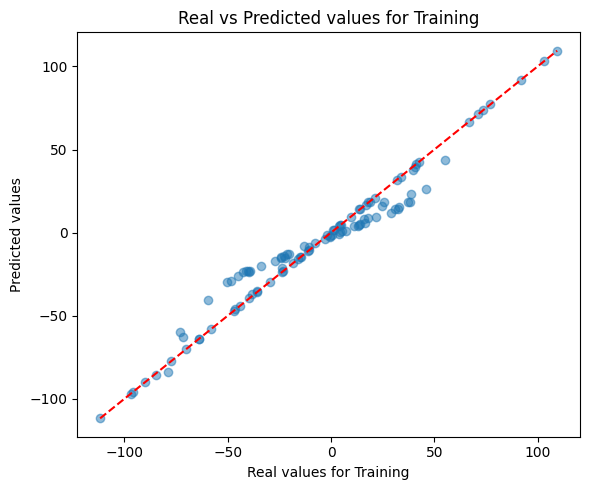

RMSE for Validation: 637.9018
Standard deviation for Validation: 48.3018
R^2 for Validation: -173.4137


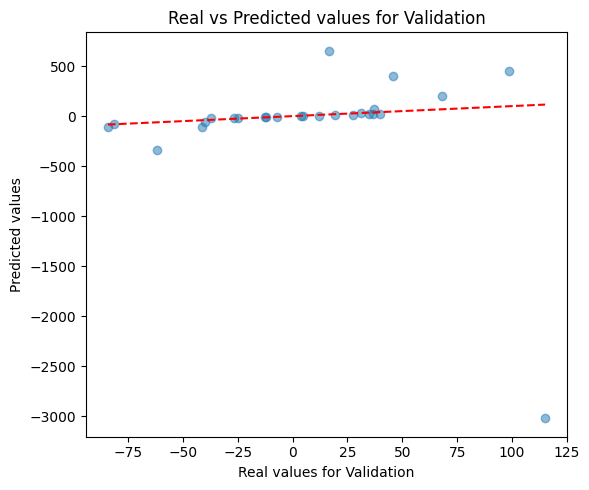

Результати моделювання з використанням Ridge
RMSE for Training: 28.6545
Standard deviation for Training: 44.1342
R^2 for Training: 0.5785


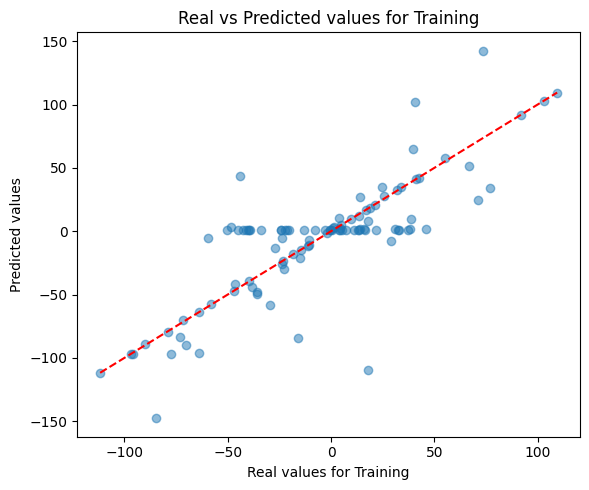

RMSE for Validation: 143896.1431
Standard deviation for Validation: 48.3018
R^2 for Validation: -8875060.5873


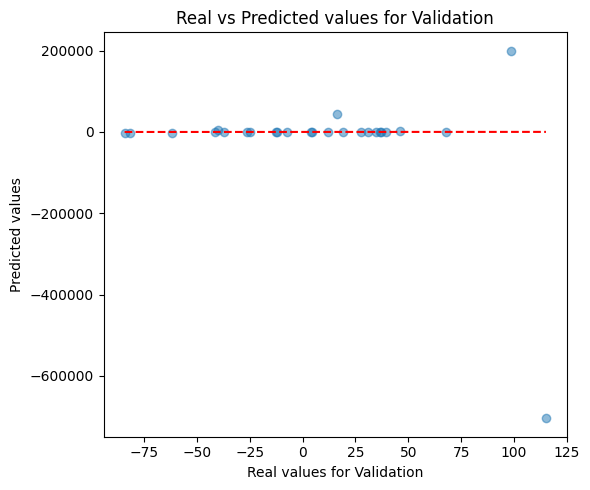

Результати моделювання з використанням ElasticNet
RMSE for Training: 24.2504
Standard deviation for Training: 44.1342
R^2 for Training: 0.6981


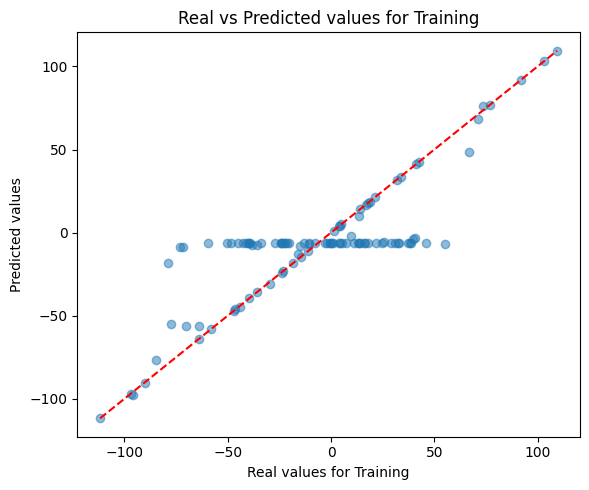

RMSE for Validation: 2919.6935
Standard deviation for Validation: 48.3018
R^2 for Validation: -3652.8238


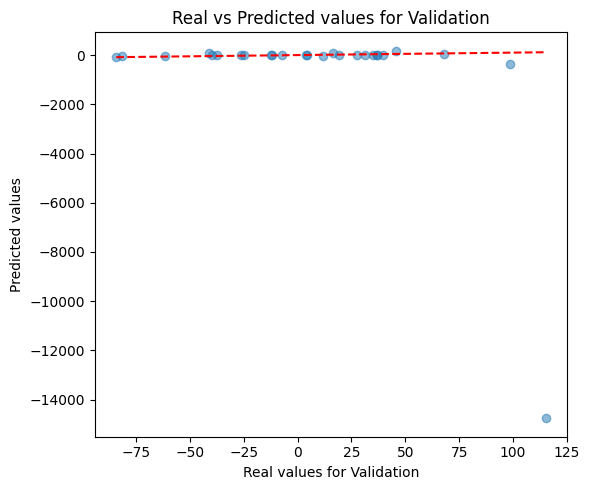

['model_pipeline_poly20_net.joblib']

In [14]:
train_df, valid_df = train_test_split(reg_raw_df, test_size=0.2, random_state=42)

# Створюємо трен. і вал. набори
train_targets = train_df[target_col].copy()
val_targets = valid_df[target_col].copy()

train_inputs = train_df[inputs_cols].copy()
val_inputs = valid_df[inputs_cols].copy()


# Виявляємо числові і категоріальні колонки
numeric_cols = train_inputs.select_dtypes("number").columns
degree = 20


# Створюємо трансформери для числових і категоріальних колонок
numeric_transformer_poly20 = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('polinom', PolynomialFeatures(degree = degree))

])

# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor_poly20 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_poly20, numeric_cols),
    ])

# Стоврюємо пайплайн, який спочатку запускає препроцесинг, потім тренуєм модель
model_pipeline_poly20_lasso = Pipeline(steps=[
    ('preprocessor', preprocessor_poly20),
    ('regressor', Lasso(alpha = 4, max_iter=10000))
])

model_pipeline_poly20_ridge = Pipeline(steps=[
    ('preprocessor', preprocessor_poly20),
    ('regressor', Ridge(alpha = 5, max_iter=10000))
])

model_pipeline_poly20_net = Pipeline(steps=[
    ('preprocessor', preprocessor_poly20),
    ('regressor', ElasticNet(alpha = 950, l1_ratio =0.7, max_iter=10000))
])

# Тренуємо пайплайн
model_pipeline_poly20_lasso.fit(train_inputs, train_targets)
model_pipeline_poly20_ridge.fit(train_inputs, train_targets)
model_pipeline_poly20_net.fit(train_inputs, train_targets)

# Функція, щоб передбачати і рахувати метрики
def predict_and_plot(targets, inputs, model_pipeline, name = ''):

    pred = model_pipeline.predict(inputs)

    rmse_ = np.sqrt(mean_squared_error(targets, pred)).round(4)
    print(f"RMSE for {name}:", rmse_)

    std_ = np.std(targets).round(4)
    print(f"Standard deviation for {name}:", std_)

    r2_ = round(r2_score(targets, pred), 4)

    print(f"R^2 for {name}:", r2_)

    plt.figure(figsize = (6, 5))

    plt.scatter(targets, pred, alpha = 0.5)
    plt.plot([targets.min(), targets.max()],
            [targets.min(), targets.max()],
            'r--')
    plt.xlabel(f"Real values for {name}")
    plt.ylabel("Predicted values")
    plt.title(f"Real vs Predicted values for {name}")
    plt.tight_layout()
    plt.show();

    return pred


# Оцінюємо модель на трен і вал даних
print("Результати моделювання з використанням Lasso")
train_lasso_preds = predict_and_plot(train_targets, train_inputs, model_pipeline_poly20_lasso, 'Training')
val_lasso_preds = predict_and_plot(val_targets, val_inputs, model_pipeline_poly20_lasso, 'Validation')

print("Результати моделювання з використанням Ridge")
train_ridge_preds = predict_and_plot(train_targets, train_inputs, model_pipeline_poly20_ridge, 'Training')
val_ridge_preds = predict_and_plot(val_targets, val_inputs, model_pipeline_poly20_ridge, 'Validation')

print("Результати моделювання з використанням ElasticNet")
train_net_preds = predict_and_plot(train_targets, train_inputs, model_pipeline_poly20_net, 'Training')
val_net_preds = predict_and_plot(val_targets, val_inputs, model_pipeline_poly20_net, 'Validation')

# Зберігаємо модель для подальшого використання
joblib.dump(model_pipeline_poly20_lasso, 'model_pipeline_poly20_lasso.joblib')
joblib.dump(model_pipeline_poly20_ridge, 'model_pipeline_poly20_ridge.joblib')
joblib.dump(model_pipeline_poly20_net, 'model_pipeline_poly20_net.joblib')


c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.767e+02, tolerance: 2.006e+01
  model = cd_fast.enet_coordinate_descent(
c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.347e+04, tolerance: 2.006e+01
  model = cd_fast.enet_coordinate_descent(
c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the sca

Результати моделювання з використанням Lasso
RMSE for Training: 8.6624
Standard deviation for Training: 44.1342
R^2 for Training: 0.9615


c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.904e+03, tolerance: 2.006e+01
  model = cd_fast.enet_coordinate_descent(


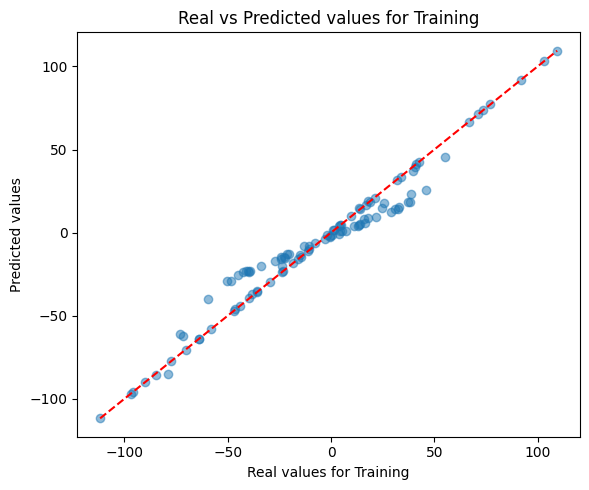

RMSE for Validation: 2214.8338
Standard deviation for Validation: 48.3018
R^2 for Validation: -2101.5936


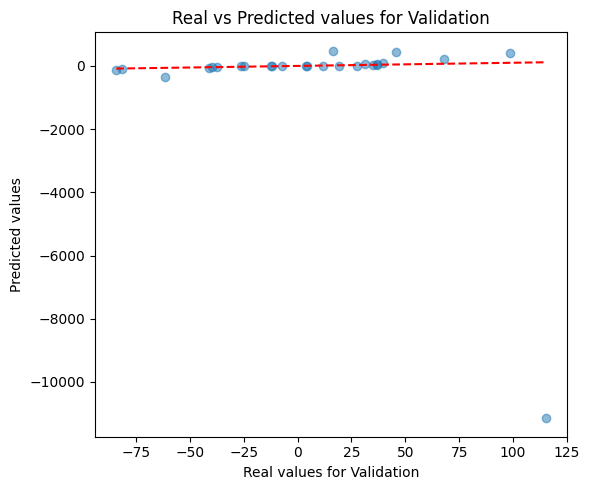

Результати моделювання з використанням Ridge
RMSE for Training: 4.1574
Standard deviation for Training: 44.1342
R^2 for Training: 0.9911


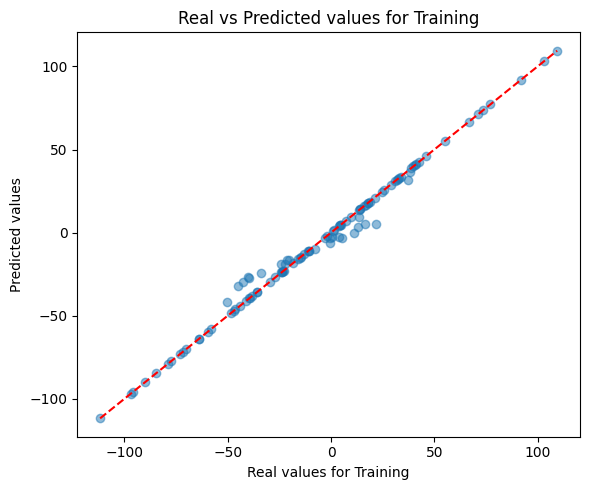

RMSE for Validation: 211279.5516
Standard deviation for Validation: 48.3018
R^2 for Validation: -19133216.1791


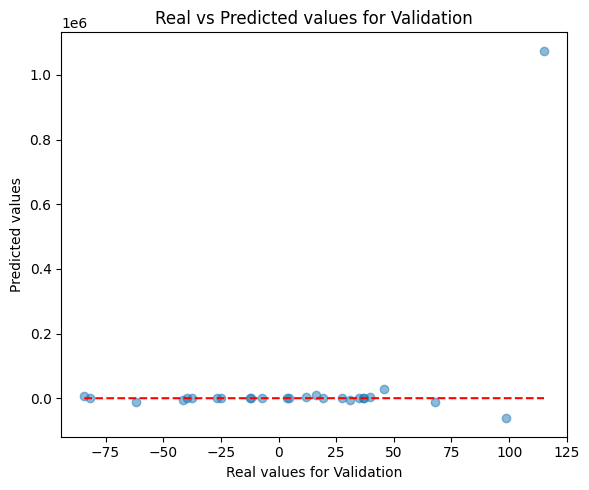

Результати моделювання з використанням ElasticNet
RMSE for Training: 24.9395
Standard deviation for Training: 44.1342
R^2 for Training: 0.6807


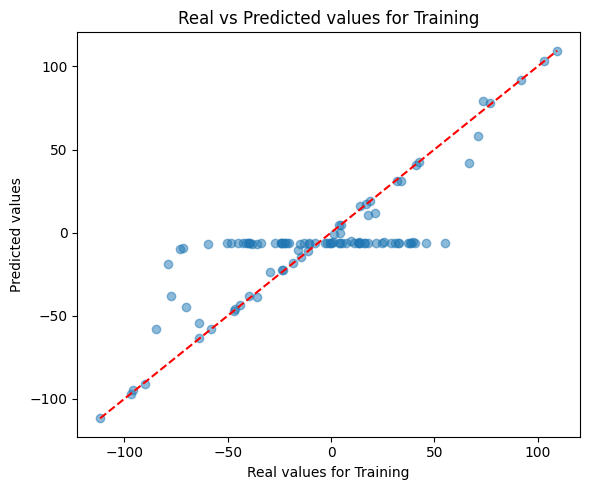

RMSE for Validation: 3818.4457
Standard deviation for Validation: 48.3018
R^2 for Validation: -6248.515


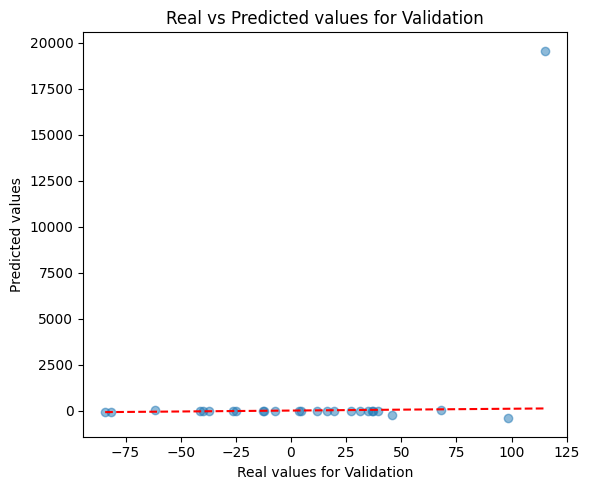

['model_pipeline_poly20_net.joblib']

In [15]:
train_df, valid_df = train_test_split(reg_raw_df, test_size=0.2, random_state=42)

# Створюємо трен. і вал. набори
train_targets = train_df[target_col].copy()
val_targets = valid_df[target_col].copy()

train_inputs = train_df[inputs_cols].copy()
val_inputs = valid_df[inputs_cols].copy()


# Виявляємо числові і категоріальні колонки
numeric_cols = train_inputs.select_dtypes("number").columns
degree = 20


# Створюємо трансформери для числових і категоріальних колонок
numeric_transformer_poly20 = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('polinom', PolynomialFeatures(degree = degree))

])

# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor_poly20 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_poly20, numeric_cols),
    ])

# Стоврюємо пайплайн, який спочатку запускає препроцесинг, потім тренуєм модель
model_pipeline_poly20_lasso = Pipeline(steps=[
    ('preprocessor', preprocessor_poly20),
    ('feature_select', SelectFromModel(Lasso(alpha=0.1, max_iter=10000))),
    ('regressor', Lasso(alpha = 4, max_iter=10000))
])

model_pipeline_poly20_ridge = Pipeline(steps=[
    ('preprocessor', preprocessor_poly20),
    ('feature_select', SelectFromModel(Lasso(alpha=0.1, max_iter=10000))),
    ('regressor', Ridge(alpha = 5, max_iter=10000))
])

model_pipeline_poly20_net = Pipeline(steps=[
    ('preprocessor', preprocessor_poly20),
    ('feature_select', SelectFromModel(Lasso(alpha=0.1, max_iter=10000))),
    ('regressor', ElasticNet(alpha = 950, l1_ratio =0.7, max_iter=10000))
])

# Тренуємо пайплайн
model_pipeline_poly20_lasso.fit(train_inputs, train_targets)
model_pipeline_poly20_ridge.fit(train_inputs, train_targets)
model_pipeline_poly20_net.fit(train_inputs, train_targets)

# Функція, щоб передбачати і рахувати метрики
def predict_and_plot(targets, inputs, model_pipeline, name = ''):

    pred = model_pipeline.predict(inputs)

    rmse_ = np.sqrt(mean_squared_error(targets, pred)).round(4)
    print(f"RMSE for {name}:", rmse_)

    std_ = np.std(targets).round(4)
    print(f"Standard deviation for {name}:", std_)

    r2_ = round(r2_score(targets, pred), 4)

    print(f"R^2 for {name}:", r2_)

    plt.figure(figsize = (6, 5))

    plt.scatter(targets, pred, alpha = 0.5)
    plt.plot([targets.min(), targets.max()],
            [targets.min(), targets.max()],
            'r--')
    plt.xlabel(f"Real values for {name}")
    plt.ylabel("Predicted values")
    plt.title(f"Real vs Predicted values for {name}")
    plt.tight_layout()
    plt.show();

    return pred


# Оцінюємо модель на трен і вал даних
print("Результати моделювання з використанням Lasso")
train_lasso_preds = predict_and_plot(train_targets, train_inputs, model_pipeline_poly20_lasso, 'Training')
val_lasso_preds = predict_and_plot(val_targets, val_inputs, model_pipeline_poly20_lasso, 'Validation')

print("Результати моделювання з використанням Ridge")
train_ridge_preds = predict_and_plot(train_targets, train_inputs, model_pipeline_poly20_ridge, 'Training')
val_ridge_preds = predict_and_plot(val_targets, val_inputs, model_pipeline_poly20_ridge, 'Validation')

print("Результати моделювання з використанням ElasticNet")
train_net_preds = predict_and_plot(train_targets, train_inputs, model_pipeline_poly20_net, 'Training')
val_net_preds = predict_and_plot(val_targets, val_inputs, model_pipeline_poly20_net, 'Validation')

# Зберігаємо модель для подальшого використання
joblib.dump(model_pipeline_poly20_lasso, 'model_pipeline_poly20_lasso.joblib')
joblib.dump(model_pipeline_poly20_ridge, 'model_pipeline_poly20_ridge.joblib')
joblib.dump(model_pipeline_poly20_net, 'model_pipeline_poly20_net.joblib')


Результати моделювання з використанням Lasso
RMSE for Training: 43.77
Standard deviation for Training: 44.1342
R^2 for Training: 0.0164


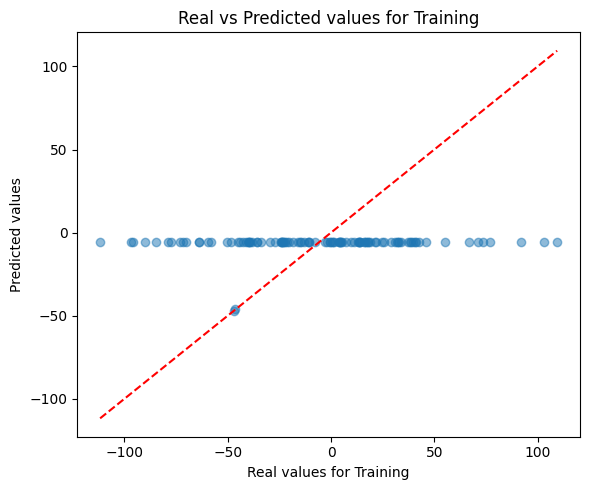

RMSE for Validation: 49.7324
Standard deviation for Validation: 48.3018
R^2 for Validation: -0.0601


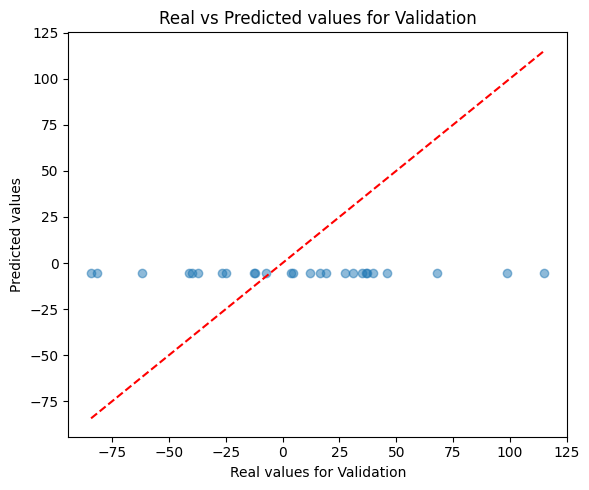

Результати моделювання з використанням Ridge
RMSE for Training: 43.77
Standard deviation for Training: 44.1342
R^2 for Training: 0.0164


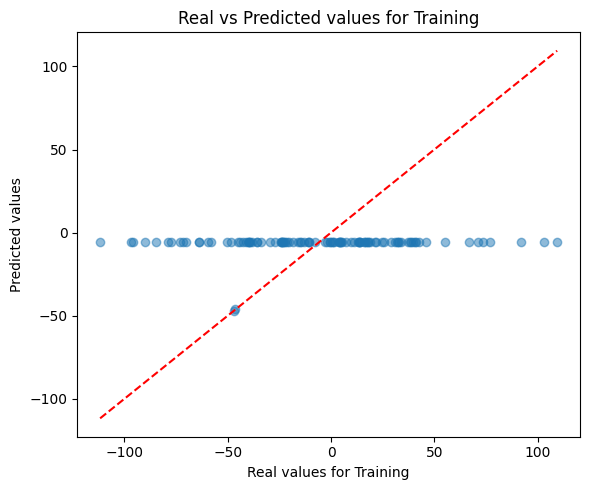

RMSE for Validation: 49.7324
Standard deviation for Validation: 48.3018
R^2 for Validation: -0.0601


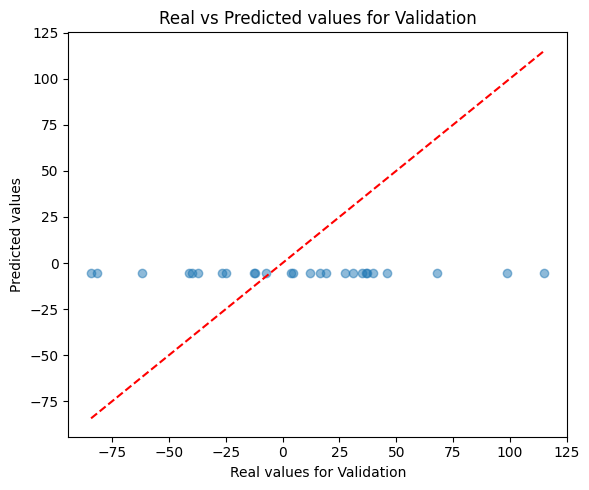

Результати моделювання з використанням ElasticNet
RMSE for Training: 43.77
Standard deviation for Training: 44.1342
R^2 for Training: 0.0164


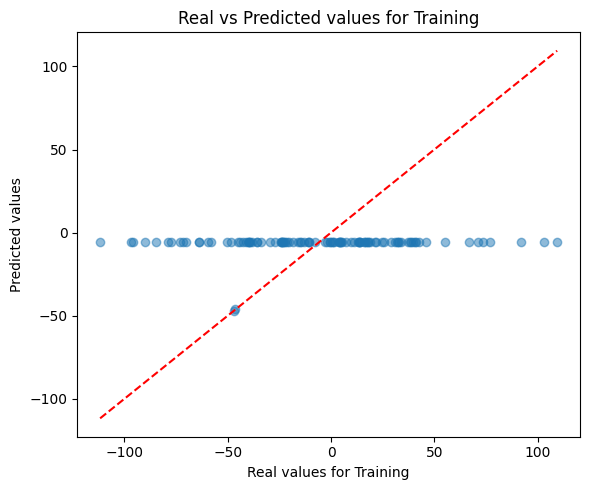

RMSE for Validation: 49.7324
Standard deviation for Validation: 48.3018
R^2 for Validation: -0.0601


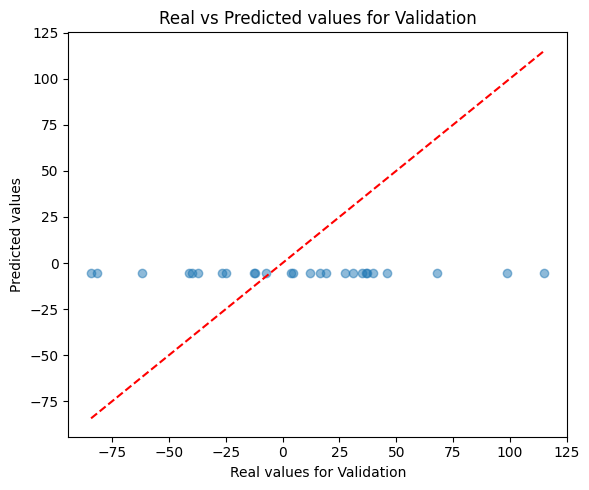

['model_pipeline_poly20_net.joblib']

In [16]:
train_df, valid_df = train_test_split(reg_raw_df, test_size=0.2, random_state=42)

# Створюємо трен. і вал. набори
train_targets = train_df[target_col].copy()
val_targets = valid_df[target_col].copy()

train_inputs = train_df[inputs_cols].copy()
val_inputs = valid_df[inputs_cols].copy()


# Виявляємо числові і категоріальні колонки
numeric_cols = train_inputs.select_dtypes("number").columns
degree = 20


# Створюємо трансформери для числових і категоріальних колонок
numeric_transformer_poly20 = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('polinom', PolynomialFeatures(degree = degree))

])

# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor_poly20 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_poly20, numeric_cols),
    ])

# Стоврюємо пайплайн, який спочатку запускає препроцесинг, потім тренуєм модель
model_pipeline_poly20_lasso = Pipeline(steps=[
    ('preprocessor', preprocessor_poly20),
    ('pca', PCA(n_components= 0.95)),
    ('regressor', Lasso(max_iter=10000))
])

model_pipeline_poly20_ridge = Pipeline(steps=[
    ('preprocessor', preprocessor_poly20),
    ('pca', PCA(n_components= 0.95)),
    ('regressor', Ridge(max_iter=10000))
])

model_pipeline_poly20_net = Pipeline(steps=[
    ('preprocessor', preprocessor_poly20),
    ('pca', PCA(n_components= 0.95)),
    ('regressor', ElasticNet(max_iter=10000))
])

# Тренуємо пайплайн
model_pipeline_poly20_lasso.fit(train_inputs, train_targets)
model_pipeline_poly20_ridge.fit(train_inputs, train_targets)
model_pipeline_poly20_net.fit(train_inputs, train_targets)

# Функція, щоб передбачати і рахувати метрики
def predict_and_plot(targets, inputs, model_pipeline, name = ''):

    pred = model_pipeline.predict(inputs)

    rmse_ = np.sqrt(mean_squared_error(targets, pred)).round(4)
    print(f"RMSE for {name}:", rmse_)

    std_ = np.std(targets).round(4)
    print(f"Standard deviation for {name}:", std_)

    r2_ = round(r2_score(targets, pred), 4)

    print(f"R^2 for {name}:", r2_)

    plt.figure(figsize = (6, 5))

    plt.scatter(targets, pred, alpha = 0.5)
    plt.plot([targets.min(), targets.max()],
            [targets.min(), targets.max()],
            'r--')
    plt.xlabel(f"Real values for {name}")
    plt.ylabel("Predicted values")
    plt.title(f"Real vs Predicted values for {name}")
    plt.tight_layout()
    plt.show();

    return pred


# Оцінюємо модель на трен і вал даних
print("Результати моделювання з використанням Lasso")
train_lasso_preds = predict_and_plot(train_targets, train_inputs, model_pipeline_poly20_lasso, 'Training')
val_lasso_preds = predict_and_plot(val_targets, val_inputs, model_pipeline_poly20_lasso, 'Validation')

print("Результати моделювання з використанням Ridge")
train_ridge_preds = predict_and_plot(train_targets, train_inputs, model_pipeline_poly20_ridge, 'Training')
val_ridge_preds = predict_and_plot(val_targets, val_inputs, model_pipeline_poly20_ridge, 'Validation')

print("Результати моделювання з використанням ElasticNet")
train_net_preds = predict_and_plot(train_targets, train_inputs, model_pipeline_poly20_net, 'Training')
val_net_preds = predict_and_plot(val_targets, val_inputs, model_pipeline_poly20_net, 'Validation')

# Зберігаємо модель для подальшого використання
joblib.dump(model_pipeline_poly20_lasso, 'model_pipeline_poly20_lasso.joblib')
joblib.dump(model_pipeline_poly20_ridge, 'model_pipeline_poly20_ridge.joblib')
joblib.dump(model_pipeline_poly20_net, 'model_pipeline_poly20_net.joblib')


If we compare the results of linear regression modeling with a 5th degree polynomial and Lasso, Ridge, and ElasticNet with a 20th degree polynomial, then linear regression is more generalized. In general, the model with a 20th degree polynomial is overtrained and is currently completely unusable (even after attempts to reduce the dimensionality).

# Models with using Surname

## Basic model taking into account the Surname attribute

F1 score on Training: 0.6723
AUROC for Training: 0.9


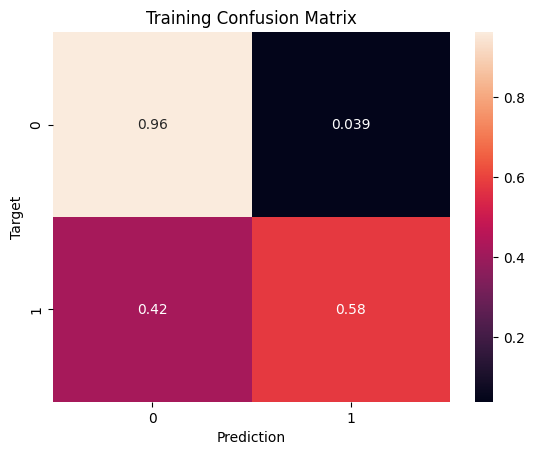

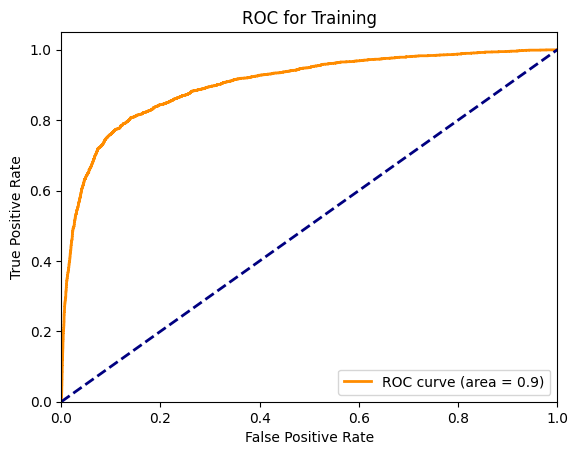

F1 score on Validation: 0.6459
AUROC for Validation: 0.88


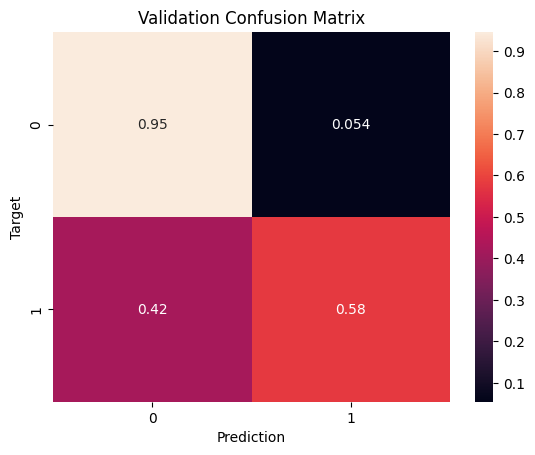

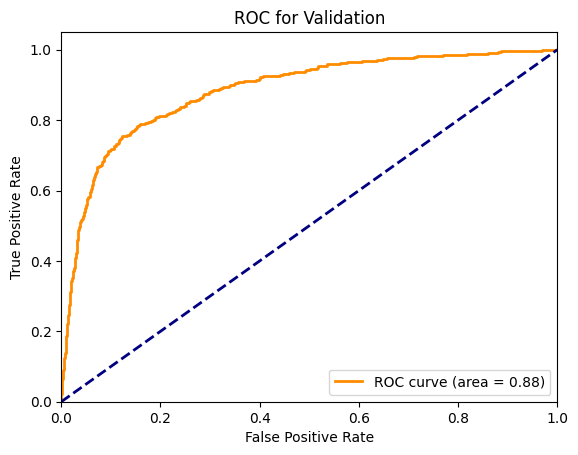

['log_reg_pipeline_sur.joblib']

In [17]:
raw_df = pd.read_csv('train.csv', index_col=0)

target_col = 'Exited'
inputs_cols = ['CreditScore', 'Surname', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']

train_df, valid_df = train_test_split(raw_df, test_size=0.2, random_state=42, stratify=raw_df[target_col])

# Створюємо трен. і вал. набори
train_targets = train_df[target_col].copy()
val_targets = valid_df[target_col].copy()

train_inputs = train_df[inputs_cols].copy()
val_inputs = valid_df[inputs_cols].copy()


# Виявляємо числові і категоріальні колонки
numeric_cols = train_inputs.select_dtypes("number").columns
categorical_cols = train_inputs.select_dtypes(exclude="number").columns
map_cols = ['Gender']
encoder_cols = ['Geography', 'Surname']
map_codes = {'Female': 1, 'Male': 0}

def map_columns(df, map_cols, map_codes):

    for col in map_cols:
        df[col] = df[col].map(map_codes)
    
    return df[[col for col in map_cols]]

map_transformer = FunctionTransformer(map_columns, kw_args = {'map_cols': map_cols, 'map_codes': map_codes})

def del_encode_col(df, cols):
    cols_to_drop = []
    for col in cols:
        if (df[col] == 0).all():
            cols_to_drop.append(col)
        else:
            most_frequent = (df[col].value_counts(normalize = True).idxmax())
            cols_to_drop.append(f"{col}_{most_frequent}")
    
    return cols_to_drop

train_cols_to_drop = del_encode_col(train_inputs, encoder_cols)

def drop_encoded_cols(df, cols_to_drop, encoder_cols):
    if not hasattr(df, 'columns'):
        df = pd.DataFrame(df)
    
    df = df.drop(columns = encoder_cols + cols_to_drop, errors='ignore')
    

    return df

dropper = FunctionTransformer(drop_encoded_cols, kw_args = {'cols_to_drop': train_cols_to_drop, 'encoder_cols': encoder_cols})

# Створюємо трансформери для числових і категоріальних колонок
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler()),

])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore')),
])

# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('map', map_transformer, map_cols),
        ('cat', categorical_transformer, encoder_cols)
    ])

# Стоврюємо пайплайн, який спочатку запускає препроцесинг, потім тренуєм модель
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('drop_cols', dropper),
    ('classifier', LogisticRegression(solver='liblinear'))
])

# Тренуємо пайплайн
model_pipeline.fit(train_inputs, train_targets)

# Функція, щоб передбачати і рахувати метрики
def predict_and_plot(targets, inputs, model_pipeline, name = ''):

    pred = model_pipeline.predict(inputs)
    pred_proba = model_pipeline.predict_proba(inputs)[:,1]
    pred_class = (pred_proba >= 0.5).astype(int)


    f1_score_value = f1_score(targets, pred_class, pos_label = True)
    print(f'F1 score on {name}: {round(f1_score_value, 4)}')


    cf = confusion_matrix(targets, pred_class, normalize = 'true')
    plt.figure()
    sns.heatmap(cf, annot = True)
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))


    fpr, tpr, thresholds = roc_curve(targets, pred_proba, pos_label = True)

    roc_auc = auc(fpr, tpr)
    print(f'AUROC for {name}: {round(roc_auc, 2)}')


    plt.figure()
    plt.plot(fpr, tpr, color = 'darkorange', lw =2, label = f'ROC curve (area = {round(roc_auc, 2)})')
    plt.plot([0, 1], [0, 1], color = 'navy', lw = 2, linestyle = '--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC for {name}')
    plt.legend(loc = "lower right")
    plt.show()

    return pred


# Оцінюємо модель на трен і вал даних
train_preds = predict_and_plot(train_targets, train_inputs, model_pipeline, 'Training')
val_preds = predict_and_plot(val_targets, val_inputs, model_pipeline, 'Validation')

# Зберігаємо модель для подальшого використання
joblib.dump(model_pipeline, 'log_reg_pipeline_sur.joblib')


## Model taking into account Surname polynomial of degree 2

F1 score on Training: 0.7621
AUROC for Training: 0.94


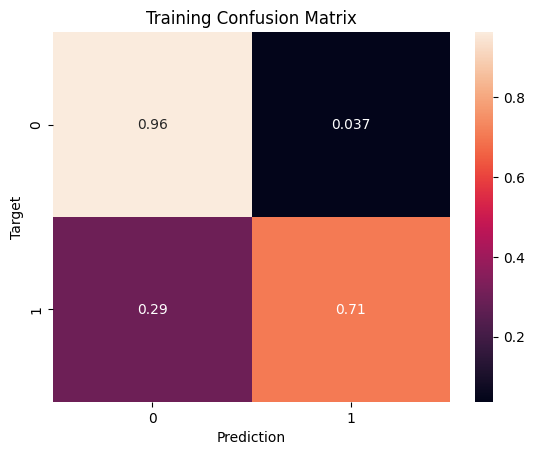

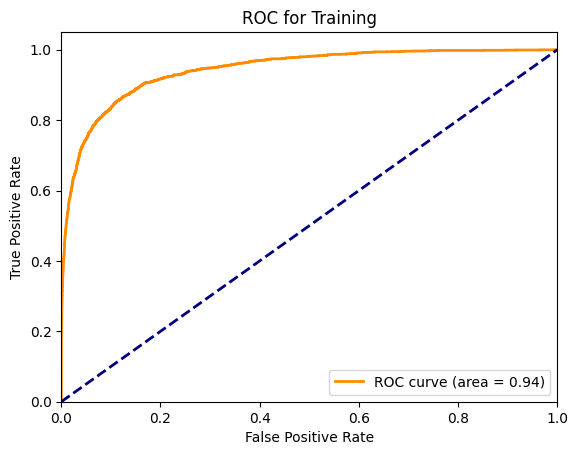

F1 score on Validation: 0.7223
AUROC for Validation: 0.93


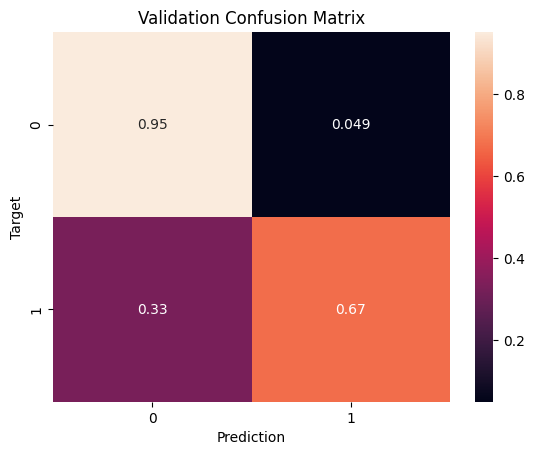

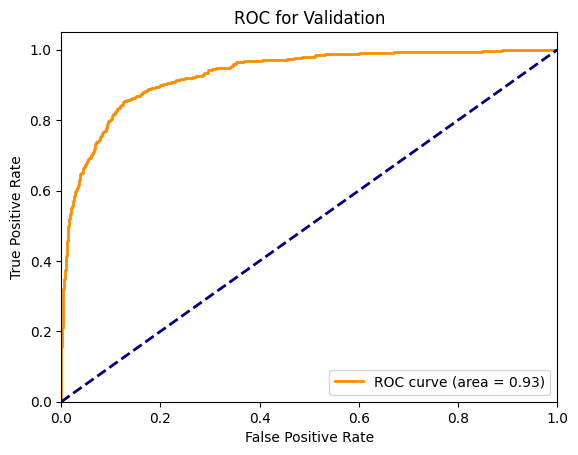

['log_reg_pipeline_sur_poly2.joblib']

In [18]:
raw_df = pd.read_csv('train.csv', index_col=0)

target_col = 'Exited'
inputs_cols = ['CreditScore', 'Geography', 'Surname', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']

train_df, valid_df = train_test_split(raw_df, test_size=0.2, random_state=42, stratify=raw_df[target_col])

# Створюємо трен. і вал. набори
train_targets = train_df[target_col].copy()
val_targets = valid_df[target_col].copy()

train_inputs = train_df[inputs_cols].copy()
val_inputs = valid_df[inputs_cols].copy()


# Виявляємо числові і категоріальні колонки
numeric_cols = train_inputs.select_dtypes("number").columns
categorical_cols = train_inputs.select_dtypes(exclude="number").columns
map_cols = ['Gender']
encoder_cols = ['Geography', 'Surname']
map_codes = {'Female': 1, 'Male': 0}
degree = 2

def map_columns(df, map_cols, map_codes):

    for col in map_cols:
        df[col] = df[col].map(map_codes)
    
    return df[[col for col in map_cols]]

map_transformer = FunctionTransformer(map_columns, kw_args = {'map_cols': map_cols, 'map_codes': map_codes})

def del_encode_col(df, cols):
    cols_to_drop = []
    for col in cols:
        if (df[col] == 0).all():
            cols_to_drop.append(col)
        else:
            most_frequent = (df[col].value_counts(normalize = True).idxmax())
            cols_to_drop.append(f"{col}_{most_frequent}")
    
    return cols_to_drop

train_cols_to_drop = del_encode_col(train_inputs, encoder_cols)

def drop_encoded_cols(df, cols_to_drop, encoder_cols):
    if not hasattr(df, 'columns'):
        df = pd.DataFrame(df)
    
    df = df.drop(columns = encoder_cols + cols_to_drop, errors='ignore')
    

    return df

dropper = FunctionTransformer(drop_encoded_cols, kw_args = {'cols_to_drop': train_cols_to_drop, 'encoder_cols': encoder_cols})

# Створюємо трансформери для числових і категоріальних колонок
numeric_transformer_poly2 = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('polinom', PolynomialFeatures(degree = degree))

])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore')),
])

# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor_poly2 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_poly2, numeric_cols),
        ('map', map_transformer, map_cols),
        ('cat', categorical_transformer, encoder_cols)
    ])

# Стоврюємо пайплайн, який спочатку запускає препроцесинг, потім тренуєм модель
model_pipeline_poly2 = Pipeline(steps=[
    ('preprocessor', preprocessor_poly2),
    ('drop_cols', dropper),
    ('classifier', LogisticRegression(solver='liblinear'))
])

# Тренуємо пайплайн
model_pipeline_poly2.fit(train_inputs, train_targets)

# Функція, щоб передбачати і рахувати метрики
def predict_and_plot(targets, inputs, model_pipeline, name = ''):

    pred = model_pipeline.predict(inputs)
    pred_proba = model_pipeline.predict_proba(inputs)[:,1]
    pred_class = (pred_proba >= 0.5).astype(int)


    f1_score_value = f1_score(targets, pred_class, pos_label = True)
    print(f'F1 score on {name}: {round(f1_score_value, 4)}')


    cf = confusion_matrix(targets, pred_class, normalize = 'true')
    plt.figure()
    sns.heatmap(cf, annot = True)
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))


    fpr, tpr, thresholds = roc_curve(targets, pred_proba, pos_label = True)

    roc_auc = auc(fpr, tpr)
    print(f'AUROC for {name}: {round(roc_auc, 2)}')


    plt.figure()
    plt.plot(fpr, tpr, color = 'darkorange', lw =2, label = f'ROC curve (area = {round(roc_auc, 2)})')
    plt.plot([0, 1], [0, 1], color = 'navy', lw = 2, linestyle = '--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC for {name}')
    plt.legend(loc = "lower right")
    plt.show()

    return pred


# Оцінюємо модель на трен і вал даних
train_preds = predict_and_plot(train_targets, train_inputs, model_pipeline_poly2, 'Training')
val_preds = predict_and_plot(val_targets, val_inputs, model_pipeline_poly2, 'Validation')

# Зберігаємо модель для подальшого використання
joblib.dump(model_pipeline_poly2, 'log_reg_pipeline_sur_poly2.joblib')


## Model taking into account Surname 4th degree polynomial

F1 score on Training: 0.7794
AUROC for Training: 0.96


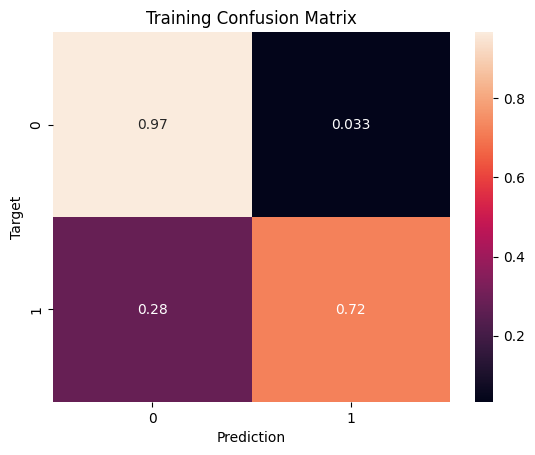

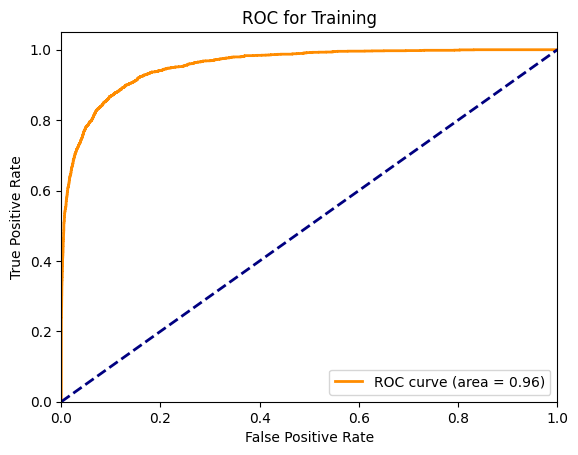

F1 score on Validation: 0.7117
AUROC for Validation: 0.93


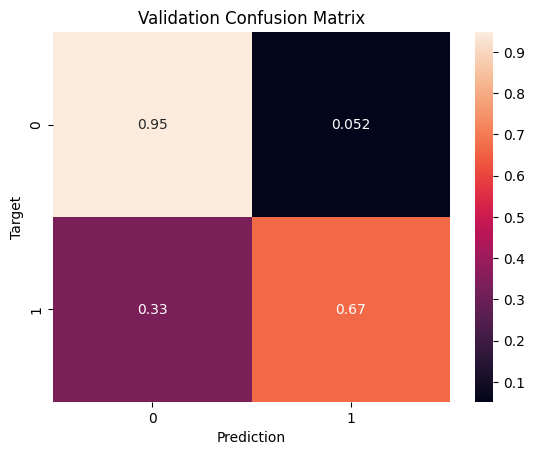

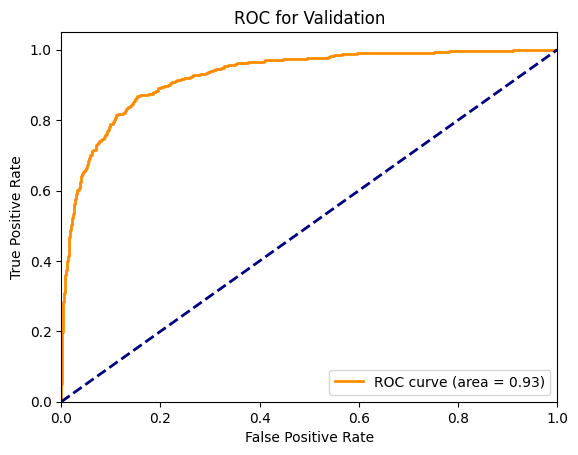

['log_reg_pipeline_sur_poly4.joblib']

In [19]:
raw_df = pd.read_csv('train.csv', index_col=0)

target_col = 'Exited'
inputs_cols = ['CreditScore', 'Surname', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']

train_df, valid_df = train_test_split(raw_df, test_size=0.2, random_state=42, stratify=raw_df[target_col])

# Створюємо трен. і вал. набори
train_targets = train_df[target_col].copy()
val_targets = valid_df[target_col].copy()

train_inputs = train_df[inputs_cols].copy()
val_inputs = valid_df[inputs_cols].copy()


# Виявляємо числові і категоріальні колонки
numeric_cols = train_inputs.select_dtypes("number").columns
categorical_cols = train_inputs.select_dtypes(exclude="number").columns
map_cols = ['Gender']
encoder_cols = ['Geography', 'Surname']
map_codes = {'Female': 1, 'Male': 0}
degree = 4

def map_columns(df, map_cols, map_codes):

    for col in map_cols:
        df[col] = df[col].map(map_codes)
    
    return df[[col for col in map_cols]]

map_transformer = FunctionTransformer(map_columns, kw_args = {'map_cols': map_cols, 'map_codes': map_codes})

def del_encode_col(df, cols):
    cols_to_drop = []
    for col in cols:
        if (df[col] == 0).all():
            cols_to_drop.append(col)
        else:
            most_frequent = (df[col].value_counts(normalize = True).idxmax())
            cols_to_drop.append(f"{col}_{most_frequent}")
    
    return cols_to_drop

train_cols_to_drop = del_encode_col(train_inputs, encoder_cols)

def drop_encoded_cols(df, cols_to_drop, encoder_cols):
    if not hasattr(df, 'columns'):
        df = pd.DataFrame(df)
    
    df = df.drop(columns = encoder_cols + cols_to_drop, errors='ignore')
    

    return df

dropper = FunctionTransformer(drop_encoded_cols, kw_args = {'cols_to_drop': train_cols_to_drop, 'encoder_cols': encoder_cols})

# Створюємо трансформери для числових і категоріальних колонок
numeric_transformer_poly4 = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('polinom', PolynomialFeatures(degree = degree))

])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore')),
])

# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor_poly4 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_poly4, numeric_cols),
        ('map', map_transformer, map_cols),
        ('cat', categorical_transformer, encoder_cols)
    ])

# Стоврюємо пайплайн, який спочатку запускає препроцесинг, потім тренуєм модель
model_pipeline_poly4 = Pipeline(steps=[
    ('preprocessor', preprocessor_poly4),
    ('drop_cols', dropper),
    ('classifier', LogisticRegression(solver='liblinear'))
])

# Тренуємо пайплайн
model_pipeline_poly4.fit(train_inputs, train_targets)

# Функція, щоб передбачати і рахувати метрики
def predict_and_plot(targets, inputs, model_pipeline, name = ''):

    pred = model_pipeline.predict(inputs)
    pred_proba = model_pipeline.predict_proba(inputs)[:,1]
    pred_class = (pred_proba >= 0.5).astype(int)


    f1_score_value = f1_score(targets, pred_class, pos_label = True)
    print(f'F1 score on {name}: {round(f1_score_value, 4)}')


    cf = confusion_matrix(targets, pred_class, normalize = 'true')
    plt.figure()
    sns.heatmap(cf, annot = True)
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))


    fpr, tpr, thresholds = roc_curve(targets, pred_proba, pos_label = True)

    roc_auc = auc(fpr, tpr)
    print(f'AUROC for {name}: {round(roc_auc, 2)}')


    plt.figure()
    plt.plot(fpr, tpr, color = 'darkorange', lw =2, label = f'ROC curve (area = {round(roc_auc, 2)})')
    plt.plot([0, 1], [0, 1], color = 'navy', lw = 2, linestyle = '--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC for {name}')
    plt.legend(loc = "lower right")
    plt.show()

    return pred


# Оцінюємо модель на трен і вал даних
train_preds = predict_and_plot(train_targets, train_inputs, model_pipeline_poly4, 'Training')
val_preds = predict_and_plot(val_targets, val_inputs, model_pipeline_poly4, 'Validation')

# Зберігаємо модель для подальшого використання
joblib.dump(model_pipeline_poly4, 'log_reg_pipeline_sur_poly4.joblib')


However, when using the Surname attribute, there is some slight overfitting, so for now we choose a model for submission without taking into account the Surname attribute.